In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

import shap
shap.initjs()

sns.set_style("darkgrid")
print("✅ Imports done!")

✅ Imports done!


In [2]:
# Cell 2 — Load model, explainer and data
with open('../models/xgb_fraud_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../models/shap_explainer.pkl', 'rb') as f:
    explainer = pickle.load(f)

X_test = pd.read_csv('../data/splits/X_test.csv')
y_test = pd.read_csv('../data/splits/y_test.csv').squeeze()

THRESHOLD = 0.5
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= THRESHOLD).astype(int)

print("✅ Everything loaded!")
print(f"\nTest samples:    {len(X_test):,}")
print(f"Actual fraud:    {y_test.sum()}")
print(f"Predicted fraud: {y_pred.sum()}")
print(f"Threshold:       {THRESHOLD}")

✅ Everything loaded!

Test samples:    56,962
Actual fraud:    98
Predicted fraud: 96
Threshold:       0.5


In [3]:
# Cell 3 — Find all 4 types of transactions
import numpy as np

# True Positives — caught fraud ✅
tp_idx = np.where((y_pred == 1) & (y_test == 1))[0]

# False Negatives — missed fraud ❌
fn_idx = np.where((y_pred == 0) & (y_test == 1))[0]

# False Positives — false alarms ⚠️
fp_idx = np.where((y_pred == 1) & (y_test == 0))[0]

# True Negatives — correct legit ✅
tn_idx = np.where((y_pred == 0) & (y_test == 0))[0]

print("=== TRANSACTION BREAKDOWN ===\n")
print(f"✅ Fraud CAUGHT (TP):         {len(tp_idx)}")
print(f"❌ Fraud MISSED (FN):         {len(fn_idx)}")
print(f"⚠️  False Alarms (FP):         {len(fp_idx):,}")
print(f"✅ Legit Correct (TN):         {len(tn_idx):,}")
print(f"\nFraud catch rate: "
      f"{len(tp_idx)/(len(tp_idx)+len(fn_idx))*100:.1f}%")
print(f"False alarm rate: "
      f"{len(fp_idx)/(len(fp_idx)+len(tn_idx))*100:.3f}%")

=== TRANSACTION BREAKDOWN ===

✅ Fraud CAUGHT (TP):         82
❌ Fraud MISSED (FN):         16
⚠️  False Alarms (FP):         14
✅ Legit Correct (TN):         56,850

Fraud catch rate: 83.7%
False alarm rate: 0.025%


In [4]:
# Cell 4 — Get sample from each type
# Pick one from each category

tp_sample = X_test.iloc[[tp_idx[0]]]   # caught fraud
fn_sample = X_test.iloc[[fn_idx[0]]]   # missed fraud
fp_sample = X_test.iloc[[fp_idx[0]]]   # false alarm
tn_sample = X_test.iloc[[tn_idx[0]]]   # correct legit

# Get probabilities for each
print("=== SAMPLE TRANSACTION PROBABILITIES ===\n")
for name, idx, sample in [
    ("✅ Caught Fraud (TP)", tp_idx[0], tp_sample),
    ("❌ Missed Fraud (FN)", fn_idx[0], fn_sample),
    ("⚠️  False Alarm (FP)",  fp_idx[0], fp_sample),
    ("✅ Correct Legit (TN)", tn_idx[0], tn_sample)
]:
    prob = y_prob[idx]
    actual = y_test.iloc[idx]
    print(f"{name}")
    print(f"   Fraud probability: {prob:.4f}")
    print(f"   Actual label:      "
          f"{'FRAUD' if actual==1 else 'LEGIT'}")
    print(f"   Predicted:         "
          f"{'FRAUD' if prob>=0.5 else 'LEGIT'}\n")

=== SAMPLE TRANSACTION PROBABILITIES ===

✅ Caught Fraud (TP)
   Fraud probability: 0.9999
   Actual label:      FRAUD
   Predicted:         FRAUD

❌ Missed Fraud (FN)
   Fraud probability: 0.2822
   Actual label:      FRAUD
   Predicted:         LEGIT

⚠️  False Alarm (FP)
   Fraud probability: 0.9966
   Actual label:      LEGIT
   Predicted:         FRAUD

✅ Correct Legit (TN)
   Fraud probability: 0.0000
   Actual label:      LEGIT
   Predicted:         LEGIT



In [5]:
# Cell 5 — Calculate SHAP values for all 4 samples
print("Calculating SHAP values...")

shap_tp = explainer.shap_values(tp_sample)
shap_fn = explainer.shap_values(fn_sample)
shap_fp = explainer.shap_values(fp_sample)
shap_tn = explainer.shap_values(tn_sample)

print("✅ SHAP values calculated for all 4 transaction types!")
print(f"\nBase value: {explainer.expected_value:.4f}")
print("(Average fraud probability across all transactions)")

Calculating SHAP values...
✅ SHAP values calculated for all 4 transaction types!

Base value: 2.6191
(Average fraud probability across all transactions)


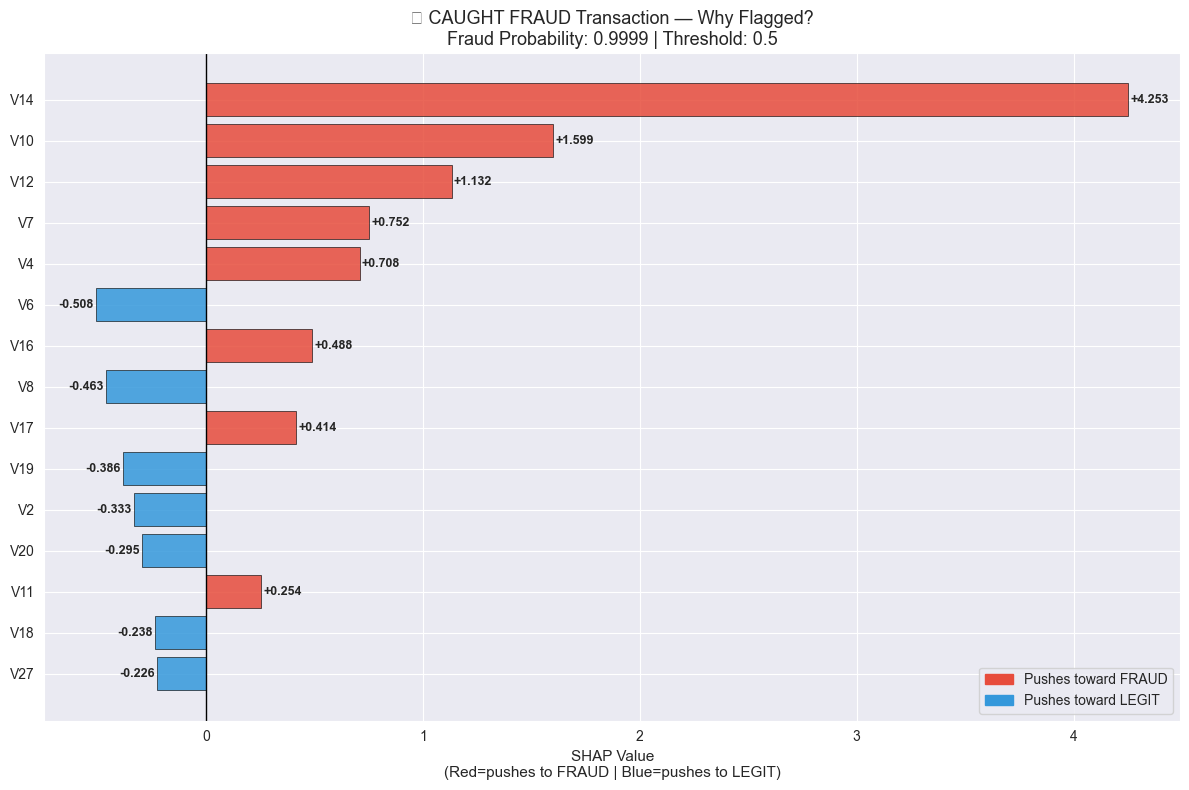

✅ shap_waterfall_caught_fraud saved!


In [6]:
# Cell 6 — Waterfall plot for CAUGHT FRAUD
def plot_waterfall(shap_vals, sample,
                   title, prob, filename):
    
    # Get feature contributions
    feature_names = sample.columns.tolist()
    shap_series = pd.Series(
        shap_vals[0], index=feature_names
    )
    
    # Sort by absolute value
    shap_sorted = shap_series.reindex(
        shap_series.abs().sort_values(
            ascending=True
        ).index
    ).tail(15)  # top 15 features
    
    # Colors
    colors = ['#e74c3c' if v > 0 else '#3498db'
              for v in shap_sorted.values]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    bars = ax.barh(
        range(len(shap_sorted)),
        shap_sorted.values,
        color=colors,
        alpha=0.85,
        edgecolor='black',
        linewidth=0.5
    )
    
    # Add value labels
    for i, (bar, val) in enumerate(
            zip(bars, shap_sorted.values)):
        ax.text(
            val + (0.01 if val >= 0 else -0.01),
            i,
            f'{val:+.3f}',
            va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=9,
            fontweight='bold'
        )
    
    ax.set_yticks(range(len(shap_sorted)))
    ax.set_yticklabels(shap_sorted.index, fontsize=10)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_xlabel('SHAP Value\n'
                  '(Red=pushes to FRAUD | '
                  'Blue=pushes to LEGIT)',
                  fontsize=11)
    ax.set_title(f'{title}\n'
                 f'Fraud Probability: {prob:.4f} | '
                 f'Threshold: 0.5',
                 fontsize=13)
    
    # Legend
    fraud_patch = mpatches.Patch(
        color='#e74c3c', label='Pushes toward FRAUD'
    )
    legit_patch = mpatches.Patch(
        color='#3498db', label='Pushes toward LEGIT'
    )
    ax.legend(handles=[fraud_patch, legit_patch],
              loc='lower right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'../data/{filename}.png',
                bbox_inches='tight')
    plt.show()
    print(f"✅ {filename} saved!")

# Plot caught fraud
plot_waterfall(
    shap_tp, tp_sample,
    "✅ CAUGHT FRAUD Transaction — Why Flagged?",
    y_prob[tp_idx[0]],
    "shap_waterfall_caught_fraud"
)

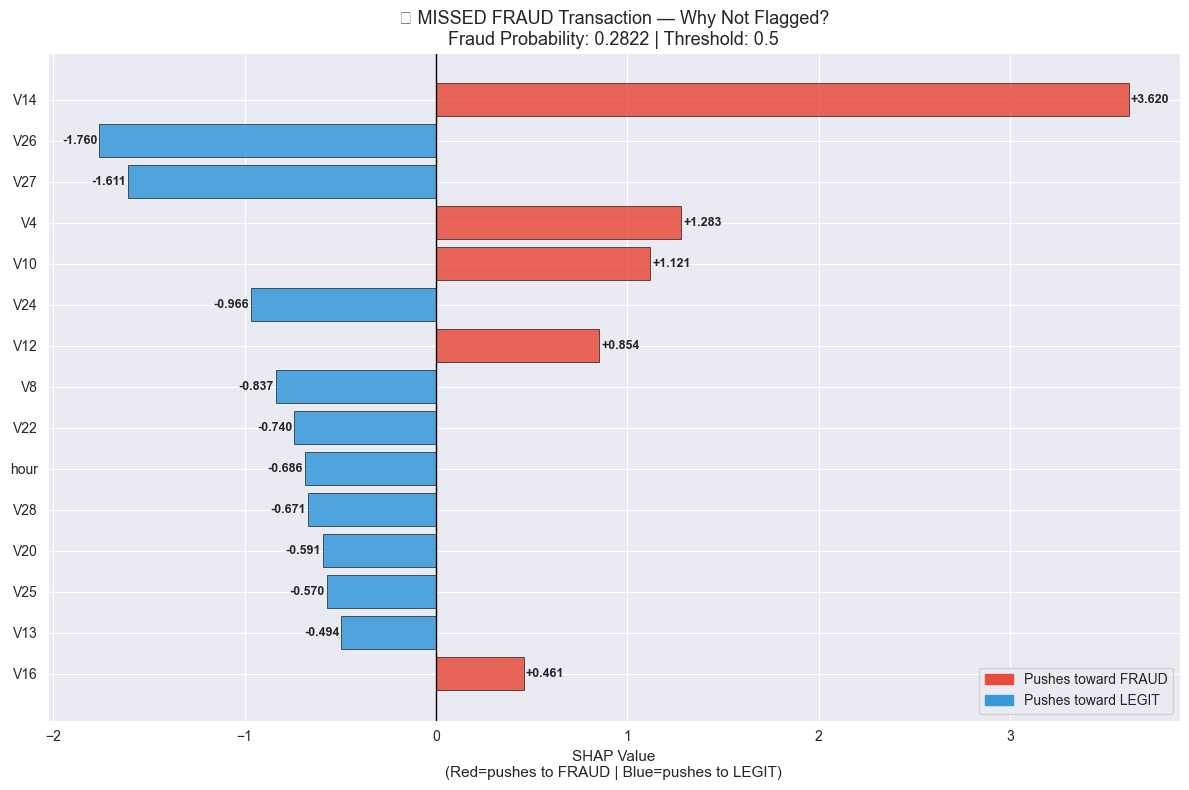

✅ shap_waterfall_missed_fraud saved!

Key insight from missed fraud:
──────────────────────────────────────────
Blue bars (legit signals) outweighed
red bars (fraud signals)

This fraud transaction had patterns
that LOOKED like legit transaction
→ Called a 'sneaky fraud' in industry

In production: lower threshold helps
catch these but increases false alarms
→ Business tradeoff decision



In [7]:
# Cell 7 — Waterfall for MISSED FRAUD
# This is very insightful — why did model miss it?

plot_waterfall(
    shap_fn, fn_sample,
    "❌ MISSED FRAUD Transaction — Why Not Flagged?",
    y_prob[fn_idx[0]],
    "shap_waterfall_missed_fraud"
)

print("""
Key insight from missed fraud:
──────────────────────────────────────────
Blue bars (legit signals) outweighed
red bars (fraud signals)

This fraud transaction had patterns
that LOOKED like legit transaction
→ Called a 'sneaky fraud' in industry

In production: lower threshold helps
catch these but increases false alarms
→ Business tradeoff decision
""")

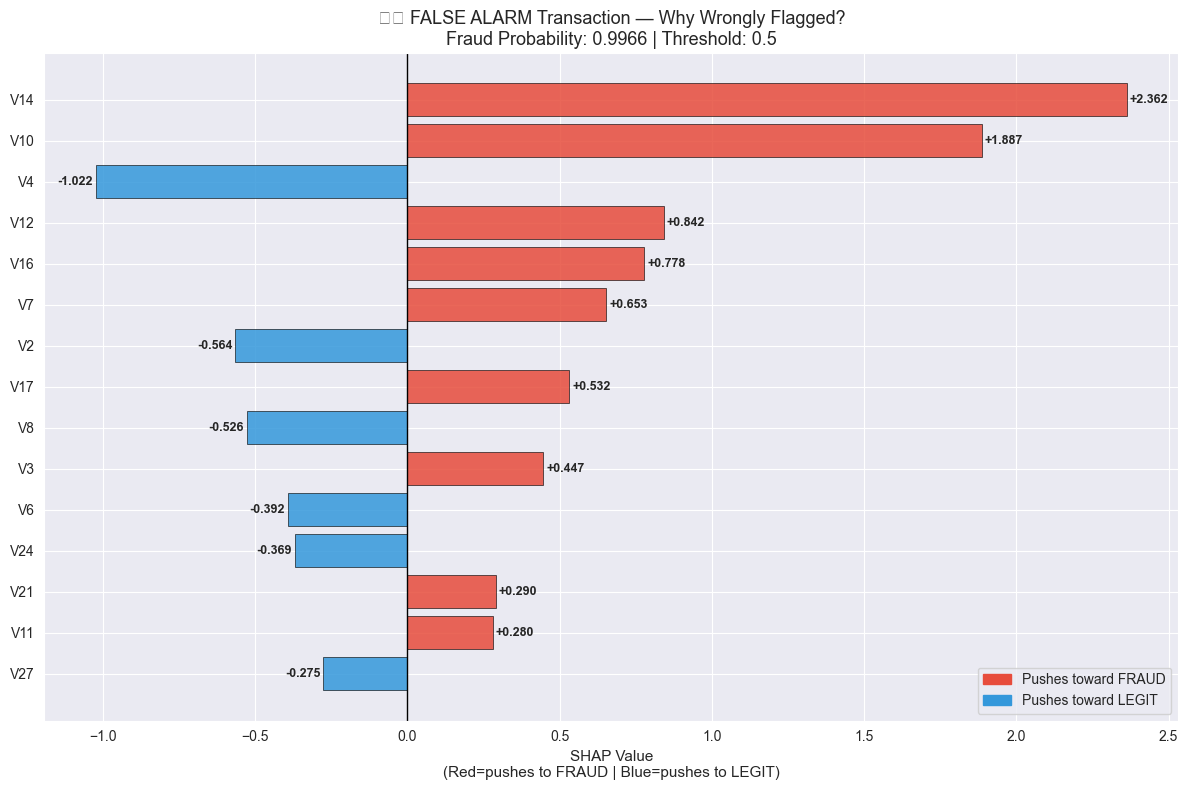

✅ shap_waterfall_false_alarm saved!

Key insight from false alarm:
──────────────────────────────────────────
This legit transaction had features
that looked suspicious to the model

Example: Legit large purchase at 2am
→ V14 pattern similar to fraud
→ Model flagged it incorrectly

In production: SHAP explanation helps
customer service explain to customer
WHY their transaction was blocked
Without SHAP: "blocked by system"
With SHAP: "flagged due to unusual
           time and amount pattern"



In [8]:
# Cell 8 — Waterfall for FALSE ALARM
# Why did model flag a legit transaction?

plot_waterfall(
    shap_fp, fp_sample,
    "⚠️ FALSE ALARM Transaction — Why Wrongly Flagged?",
    y_prob[fp_idx[0]],
    "shap_waterfall_false_alarm"
)

print("""
Key insight from false alarm:
──────────────────────────────────────────
This legit transaction had features
that looked suspicious to the model

Example: Legit large purchase at 2am
→ V14 pattern similar to fraud
→ Model flagged it incorrectly

In production: SHAP explanation helps
customer service explain to customer
WHY their transaction was blocked
Without SHAP: "blocked by system"
With SHAP: "flagged due to unusual
           time and amount pattern"
""")

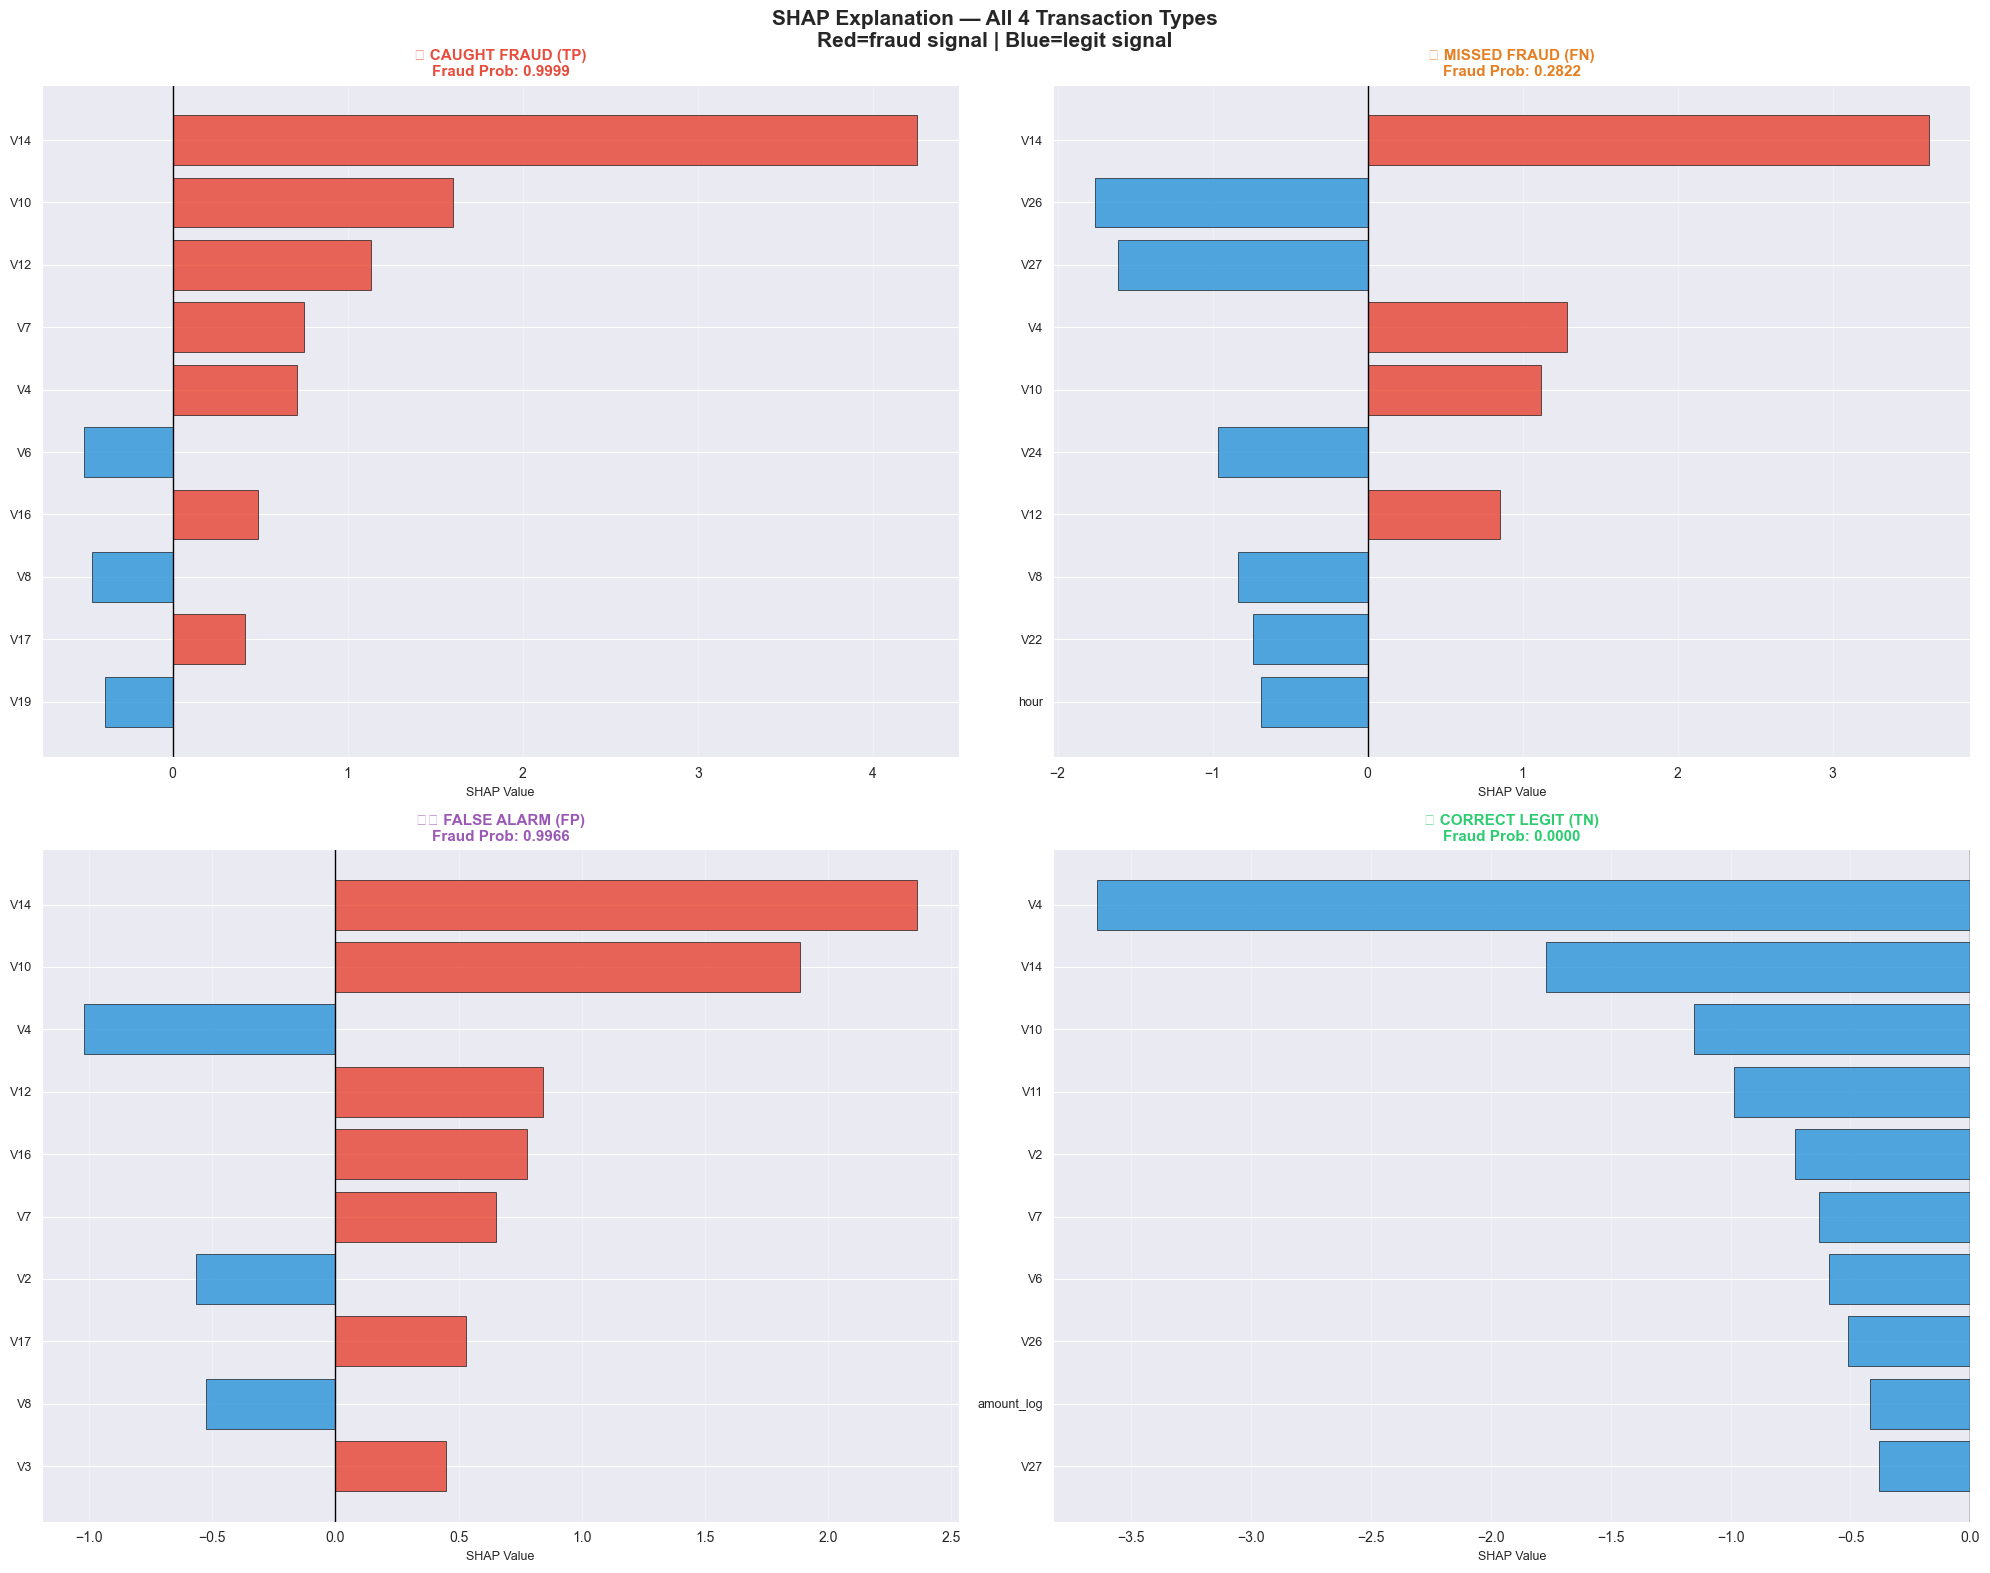

✅ All 4 types comparison saved!


In [9]:
# Cell 9 — Side by side comparison
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

transaction_types = [
    (shap_tp, tp_sample, tp_idx[0],
     "✅ CAUGHT FRAUD (TP)", '#e74c3c'),
    (shap_fn, fn_sample, fn_idx[0],
     "❌ MISSED FRAUD (FN)", '#e67e22'),
    (shap_fp, fp_sample, fp_idx[0],
     "⚠️ FALSE ALARM (FP)", '#9b59b6'),
    (shap_tn, tn_sample, tn_idx[0],
     "✅ CORRECT LEGIT (TN)", '#2ecc71')
]

for ax, (shap_vals, sample, idx,
          title, color) in zip(
    axes.flatten(), transaction_types
):
    feature_names = sample.columns.tolist()
    shap_series = pd.Series(
        shap_vals[0], index=feature_names
    )
    shap_sorted = shap_series.reindex(
        shap_series.abs().sort_values(
            ascending=True
        ).index
    ).tail(10)

    bar_colors = ['#e74c3c' if v > 0
                  else '#3498db'
                  for v in shap_sorted.values]

    ax.barh(range(len(shap_sorted)),
            shap_sorted.values,
            color=bar_colors,
            alpha=0.85,
            edgecolor='black',
            linewidth=0.5)

    ax.set_yticks(range(len(shap_sorted)))
    ax.set_yticklabels(shap_sorted.index,
                       fontsize=9)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(
        f'{title}\n'
        f'Fraud Prob: {y_prob[idx]:.4f}',
        fontsize=11,
        color=color,
        fontweight='bold'
    )
    ax.set_xlabel('SHAP Value', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    'SHAP Explanation — All 4 Transaction Types\n'
    'Red=fraud signal | Blue=legit signal',
    fontsize=15,
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('../data/shap_all_4_types.png',
            bbox_inches='tight')
plt.show()
print("✅ All 4 types comparison saved!")

=== TOP 5 HIGHEST CONFIDENCE FRAUD DETECTIONS ===



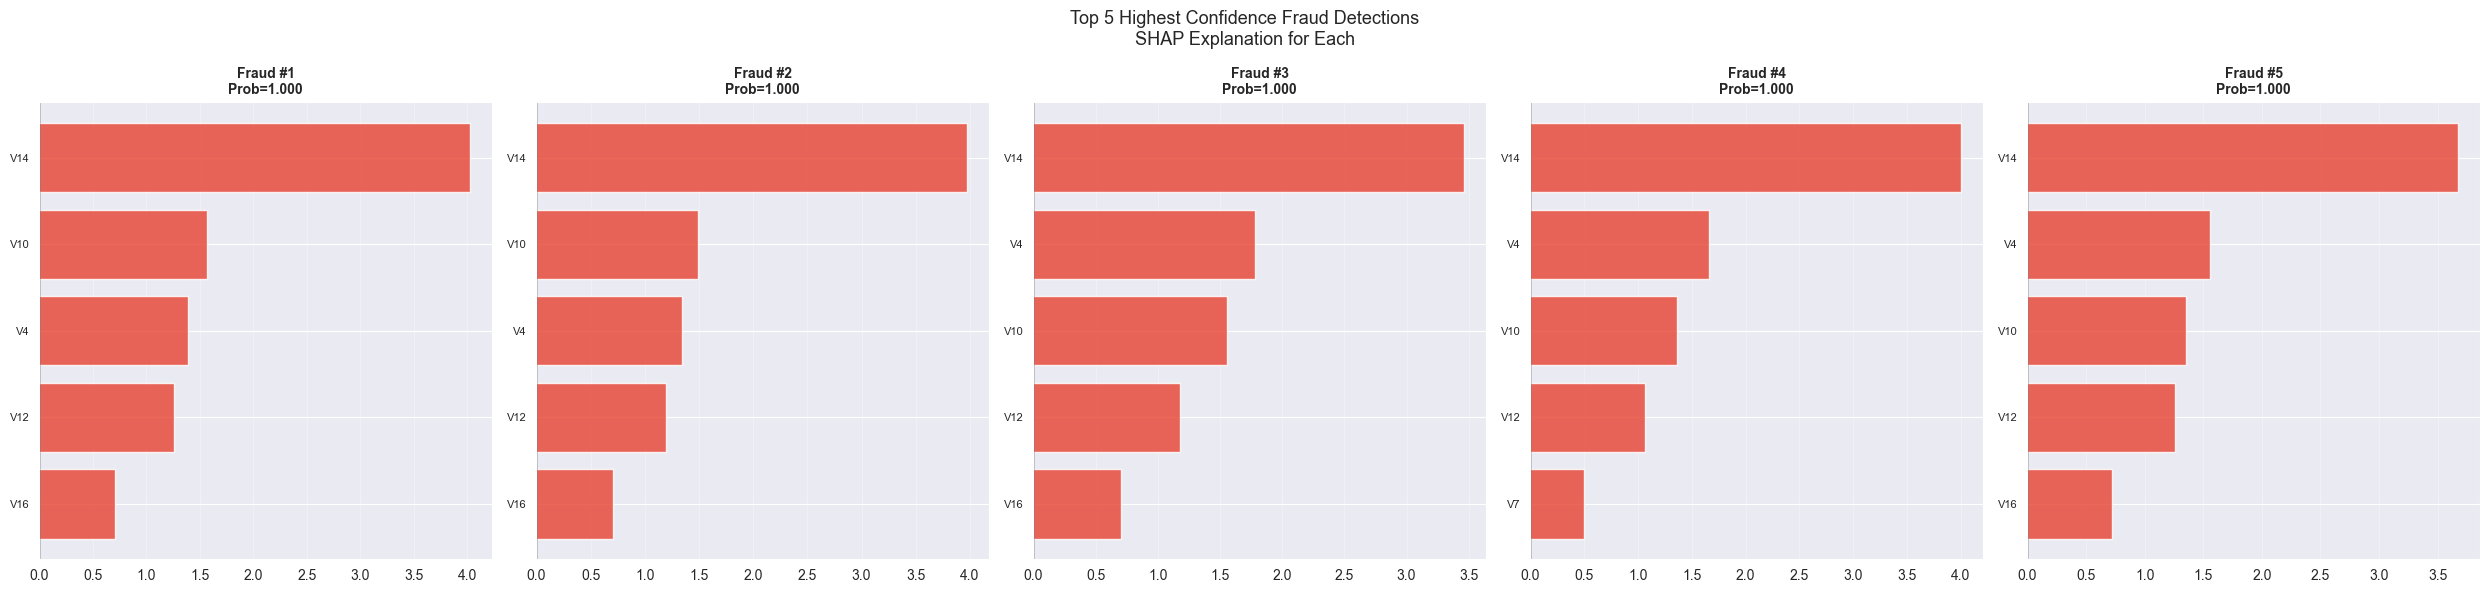


Top 5 fraud probabilities:
  #1: 1.0000
  #2: 1.0000
  #3: 1.0000
  #4: 1.0000
  #5: 1.0000


In [10]:
# Cell 10 — Analyze top 5 highest confidence frauds
print("=== TOP 5 HIGHEST CONFIDENCE FRAUD DETECTIONS ===\n")

# Sort TP by fraud probability
tp_probs = [(idx, y_prob[idx]) for idx in tp_idx]
tp_probs_sorted = sorted(
    tp_probs, key=lambda x: x[1], reverse=True
)

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for rank, (ax, (idx, prob)) in enumerate(
    zip(axes, tp_probs_sorted[:5]), 1
):
    sample = X_test.iloc[[idx]]
    shap_vals = explainer.shap_values(sample)

    shap_series = pd.Series(
        shap_vals[0],
        index=X_test.columns
    )
    top5_features = shap_series.reindex(
        shap_series.abs().sort_values(
            ascending=True
        ).index
    ).tail(5)

    colors = ['#e74c3c' if v > 0
              else '#3498db'
              for v in top5_features.values]

    ax.barh(range(5),
            top5_features.values,
            color=colors,
            alpha=0.85)
    ax.set_yticks(range(5))
    ax.set_yticklabels(top5_features.index,
                       fontsize=8)
    ax.axvline(x=0, color='black', linewidth=1)
    ax.set_title(f'Fraud #{rank}\n'
                 f'Prob={prob:.3f}',
                 fontsize=10,
                 fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

plt.suptitle(
    'Top 5 Highest Confidence Fraud Detections\n'
    'SHAP Explanation for Each',
    fontsize=13
)
plt.tight_layout()
plt.savefig('../data/shap_top5_frauds.png',
            bbox_inches='tight')
plt.show()

print("\nTop 5 fraud probabilities:")
for rank, (idx, prob) in enumerate(
    tp_probs_sorted[:5], 1
):
    print(f"  #{rank}: {prob:.4f}")

In [11]:
# Cell 11 — Reusable explanation function
def explain_transaction(transaction_data,
                        model, explainer,
                        threshold=0.5):
    """
    Explains why a transaction was flagged or not.
    Returns human readable explanation.

    Parameters:
    -----------
    transaction_data : pd.DataFrame (1 row)
    model           : trained XGBoost model
    explainer       : SHAP TreeExplainer
    threshold       : decision threshold

    Returns:
    --------
    dict with prediction and explanation
    """

    # Get prediction
    prob = model.predict_proba(
        transaction_data
    )[0][1]
    is_fraud = prob >= threshold

    # Get SHAP values
    shap_vals = explainer.shap_values(
        transaction_data
    )[0]

    # Create feature contribution df
    contributions = pd.DataFrame({
        'feature': transaction_data.columns,
        'value': transaction_data.values[0],
        'shap_value': shap_vals
    }).sort_values('shap_value',
                   key=abs,
                   ascending=False)

    # Top fraud reasons
    fraud_reasons = contributions[
        contributions['shap_value'] > 0
    ].head(3)

    # Top legit reasons
    legit_reasons = contributions[
        contributions['shap_value'] < 0
    ].head(3)

    # Build explanation
    explanation = {
        'fraud_probability': round(float(prob), 4),
        'is_fraud': bool(is_fraud),
        'risk_level': (
            'HIGH' if prob > 0.7
            else 'MEDIUM' if prob > 0.4
            else 'LOW'
        ),
        'top_fraud_signals': [
            {
                'feature': row['feature'],
                'contribution': round(
                    float(row['shap_value']), 4
                )
            }
            for _, row in fraud_reasons.iterrows()
        ],
        'top_legit_signals': [
            {
                'feature': row['feature'],
                'contribution': round(
                    float(row['shap_value']), 4
                )
            }
            for _, row in legit_reasons.iterrows()
        ],
        'base_rate': round(
            float(explainer.expected_value), 4
        )
    }

    return explanation


# Test the function on a caught fraud
test_transaction = X_test.iloc[[tp_idx[0]]]
result = explain_transaction(
    test_transaction, model, explainer
)

print("=== TRANSACTION EXPLANATION ===\n")
print(f"Fraud Probability: {result['fraud_probability']}")
print(f"Is Fraud:          {result['is_fraud']}")
print(f"Risk Level:        {result['risk_level']}")
print(f"\nTop Fraud Signals:")
for signal in result['top_fraud_signals']:
    print(f"  {signal['feature']}: "
          f"+{signal['contribution']}")
print(f"\nTop Legit Signals:")
for signal in result['top_legit_signals']:
    print(f"  {signal['feature']}: "
          f"{signal['contribution']}")

=== TRANSACTION EXPLANATION ===

Fraud Probability: 0.9999
Is Fraud:          True
Risk Level:        HIGH

Top Fraud Signals:
  V14: +4.2528
  V10: +1.5993
  V12: +1.1324

Top Legit Signals:
  V6: -0.5081
  V8: -0.4631
  V19: -0.3857


In [12]:
# Cell 12 — Save explanation function
import pickle
import os

# Save function for FastAPI use
with open('../models/explain_transaction.pkl', 'wb') as f:
    pickle.dump(explain_transaction, f)

print("✅ Explanation function saved!")
print("\nFiles ready for deployment:")
print("  models/xgb_fraud_model.pkl    ← model")
print("  models/shap_explainer.pkl     ← explainer")
print("  models/explain_transaction.pkl ← function")
print("  models/threshold_config.json  ← threshold")
print("\nAll ready for FastAPI on Day 15! 🚀")

✅ Explanation function saved!

Files ready for deployment:
  models/xgb_fraud_model.pkl    ← model
  models/shap_explainer.pkl     ← explainer
  models/explain_transaction.pkl ← function
  models/threshold_config.json  ← threshold

All ready for FastAPI on Day 15! 🚀
